# Apartment for Rent Classified -  Data Exploration

## Project Question

Can monthly apartment rental prices be predicted using property characteristics and location information?

This project is gonna investigate apartment's rent price prediction as a supervised regression problem.

## Dataset

The Apartment for Rent Classified dataset is taken from the UCI Machine Learning Repository. The 10K version of the dataset is used for this investigation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(
    "../data/apartments_for_rent_classified_10K.csv",
    sep=";",
    encoding="latin1"
)

In [5]:
df.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [6]:
df.shape

(10000, 22)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   category       10000 non-null  str    
 2   title          10000 non-null  str    
 3   body           10000 non-null  str    
 4   amenities      6451 non-null   str    
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  str    
 8   fee            10000 non-null  str    
 9   has_photo      10000 non-null  str    
 10  pets_allowed   5837 non-null   str    
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  str    
 13  price_type     10000 non-null  str    
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   str    
 16  cityname       9923 non-null   str    
 17  state          9923 non-null   str    
 18  latitude       999

In [22]:
df.sample(5, random_state=42)

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
6252,5509158654,housing/rent/apartment,Lease Spacious 2+2. Approx 930 sf of Living Sp...,Come see all of the new and exciting improveme...,"Clubhouse,Gym,Parking,Patio/Deck,Storage,Tennis",2.0,2.0,USD,No,Yes,...,$965,Monthly,930,NaN,Durham,NC,36.0514,-78.8807,RentDigs.com,1568777002
4684,5668638788,housing/rent/apartment,Two BR 15 Union Street,"This unit is located at fifteen Union Street, ...",NaN,1.0,2.0,USD,No,Thumbnail,...,"$1,875",Monthly,786,15 Union St,New Brunswick,NJ,40.4841,-74.4526,RentLingo,1577360262
1731,5668622404,housing/rent/apartment,Studio apartment 20-28 E Daniels,"This unit is located at 20-28 E Daniels, Cinci...","Cable or Satellite,Dishwasher,Garbage Disposal...",1.0,2.0,USD,No,Thumbnail,...,$985,Monthly,585,20-28 E Daniels,Cincinnati,OH,39.1679,-84.4933,RentLingo,1577359119
4742,5509154930,housing/rent/apartment,One BR - Welcome to Spring Creek of Edmond Apa...,"Square footage: 790 sq-ft, unit number: 320. W...","Fireplace,Garbage Disposal,Gym,Patio/Deck,Pool...",1.0,1.0,USD,No,Thumbnail,...,$719,Monthly,790,NaN,Edmond,OK,35.6217,-97.4702,RentDigs.com,1568776675
4521,5668635773,housing/rent/apartment,One BR 691 BLOOMFIELD AVENUE,"This unit is located at 691 BLOOMFIELD AVENUE,...",NaN,1.0,1.0,USD,No,Thumbnail,...,"$2,250",Monthly,775,691 Bloomfield Ave,Montclair,NJ,40.8206,-74.2133,RentLingo,1577360064


In [15]:
df.isna().mean().sort_values(ascending=False) #proportion of missing values in each column


pets_allowed     0.4163
amenities        0.3549
address          0.3327
cityname         0.0077
state            0.0077
bathrooms        0.0034
latitude         0.0010
longitude        0.0010
bedrooms         0.0007
category         0.0000
title            0.0000
body             0.0000
id               0.0000
fee              0.0000
price_type       0.0000
price_display    0.0000
price            0.0000
has_photo        0.0000
currency         0.0000
square_feet      0.0000
source           0.0000
time             0.0000
dtype: float64

In [16]:
df.nunique().sort_values() #number of unique values


currency             1
fee                  1
has_photo            3
category             3
price_type           3
pets_allowed         3
bedrooms            10
source              12
bathrooms           14
state               51
cityname          1574
price             1725
price_display     1726
square_feet       1738
amenities         2254
longitude         2392
latitude          2395
time              6310
address           6658
title             9350
body              9961
id               10000
dtype: int64

In [27]:
df.duplicated().sum()

np.int64(0)

# Exploring Price - Target Variable

In [18]:
df["price"].describe()

count    10000.000000
mean      1486.277500
std       1076.507968
min        200.000000
25%        949.000000
50%       1270.000000
75%       1695.000000
max      52500.000000
Name: price, dtype: float64

In [19]:
df["price"].sort_values().head(10) # exploring minimum rental prices

181     200
1751    224
235     275
4435    288
475     300
263     325
364     350
2450    350
1004    365
4428    369
Name: price, dtype: int64

In [20]:
df["price"].sort_values(ascending=False).head(10) # exploring maximum rental prices

8829    52500
9996    25000
9990    19500
9972    14950
8581    13500
9825    13000
9997    11000
8573    11000
9946    11000
9227    10600
Name: price, dtype: int64

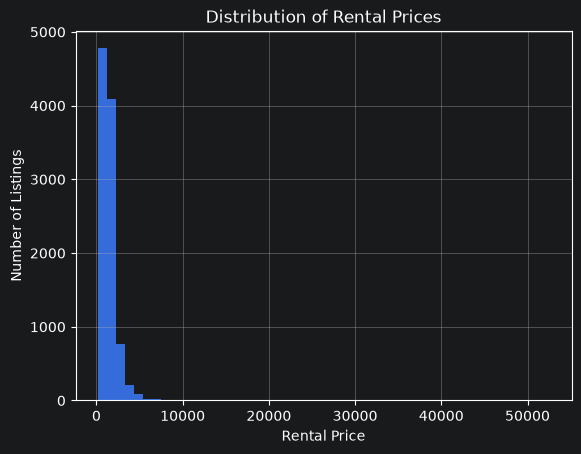

In [21]:
# target distribution
df["price"].hist(bins=50)
plt.xlabel("Rental Price")
plt.ylabel("Number of Listings")
plt.title("Distribution of Rental Prices")
plt.show()

In [23]:
df["price_type"].value_counts(dropna=False)

price_type
Monthly           9998
Weekly               1
Monthly|Weekly       1
Name: count, dtype: int64

In [24]:
df["currency"].value_counts(dropna=False)


currency
USD    10000
Name: count, dtype: int64

In [25]:
df["state"].value_counts(dropna=False)


state
TX     1737
CA      955
WA      519
NC      438
MD      424
NJ      383
GA      372
FL      339
OH      321
CO      318
WI      302
IL      282
IN      239
MO      239
MN      221
VA      205
OR      197
PA      183
IA      179
OK      178
MI      176
MA      167
AZ      126
NV      121
ND      113
NE      105
CT       98
TN       92
UT       84
KS       83
DC       80
NaN      77
SC       77
NY       71
NH       70
LA       66
SD       66
AL       56
AR       56
AK       44
KY       40
ID       21
VT       16
NM       14
HI       12
RI       11
MS        9
MT        7
DE        5
WV        3
ME        2
WY        1
Name: count, dtype: int64

In [26]:
df[["price", "bedrooms", "bathrooms", "square_feet"]].describe()

,price,bedrooms,bathrooms,square_feet
count,10000.000000,9993.000000,9966.000000,10000.000000
mean,1486.277500,1.744021,1.380544,945.810500
std,1076.507968,0.942354,0.615410,655.755736
min,200.000000,0.000000,1.000000,101.000000
25%,949.000000,1.000000,1.000000,649.000000
50%,1270.000000,2.000000,1.000000,802.000000
75%,1695.000000,2.000000,2.000000,1100.000000
max,52500.000000,9.000000,8.500000,40000.000000
